### 导入包并初始化设备

In [2]:
# Cell 1: 安装依赖、挂载Google Drive、设置路径


import os
import json
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from transformers import BertTokenizer

# 挂载Google Drive
drive.mount('/content/drive')

# 设置数据路径（请根据实际位置修改）
DATA_PATH = './xjtu-ml-class/exp/data/SQuAD'
TRAIN_FILE = os.path.join(DATA_PATH, 'SQuAD-train-v2.0.json')
DEV_FILE = os.path.join(DATA_PATH, 'SQuAD-dev-v2.0.json')
CHECKPOINT_DIR = '/content/drive/MyDrive/SQuAD_checkpoints/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


### 定义数据集类与数据加载器

In [3]:
# Cell 2: SQuAD Dataset with BertTokenizer

class SQuADDataset(Dataset):
    def __init__(self, json_path, tokenizer, max_length=384, is_train=True):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.is_train = is_train
        with open(json_path, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)
        self.examples = self._extract_examples(raw_data)
        self.input_ids = []
        self.attention_mask = []
        self.start_positions = []
        self.end_positions = []
        self._tokenize()
        print(f"Loaded {len(self.examples)} valid examples from {json_path}")

    def _extract_examples(self, raw_data):
        examples = []
        for article in raw_data['data']:
            for para in article['paragraphs']:
                context = para['context']
                for qa in para['qas']:
                    if qa.get('is_impossible', False):
                        continue
                    if not qa.get('answers'):
                        continue
                    ans = qa['answers'][0]
                    examples.append({
                        'context': context,
                        'question': qa['question'],
                        'answer_text': ans['text'],
                        'answer_start_char': ans['answer_start']
                    })
        return examples

    def _tokenize(self):
        skipped = 0
        for ex in tqdm(self.examples, desc="Tokenizing"):
            enc = self.tokenizer(
                ex['question'], ex['context'],
                max_length=self.max_length,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
                return_offsets_mapping=True
            )
            input_ids = enc['input_ids'].squeeze(0)
            att_mask = enc['attention_mask'].squeeze(0)
            offsets = enc['offset_mapping'].squeeze(0).tolist()

            if self.is_train:
                start_char = ex['answer_start_char']
                end_char = start_char + len(ex['answer_text'])
                start_token, end_token = None, None
                for i, (tok_start, tok_end) in enumerate(offsets):
                    if tok_start == 0 and tok_end == 0:
                        continue
                    if tok_start <= start_char < tok_end:
                        start_token = i
                    if tok_start < end_char <= tok_end:
                        end_token = i
                if start_token is None or end_token is None:
                    skipped += 1
                    continue
                self.start_positions.append(start_token)
                self.end_positions.append(end_token)

            self.input_ids.append(input_ids)
            self.attention_mask.append(att_mask)

        print(f"Skipped {skipped} examples (answer span not found)")
        self.input_ids = torch.stack(self.input_ids)
        self.attention_mask = torch.stack(self.attention_mask)
        if self.is_train:
            self.start_positions = torch.tensor(self.start_positions, dtype=torch.long)
            self.end_positions = torch.tensor(self.end_positions, dtype=torch.long)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        if self.is_train:
            return {
                'input_ids': self.input_ids[idx],
                'attention_mask': self.attention_mask[idx],
                'start_pos': self.start_positions[idx],
                'end_pos': self.end_positions[idx]
            }
        else:
            return {
                'input_ids': self.input_ids[idx],
                'attention_mask': self.attention_mask[idx]
            }


def create_dataloaders(train_path, dev_path, batch_size=16, max_length=384):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    train_dataset = SQuADDataset(train_path, tokenizer, max_length, is_train=True)
    dev_dataset = SQuADDataset(dev_path, tokenizer, max_length, is_train=True)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, dev_loader, tokenizer

### 实现Transformer基类

In [4]:
# Cell 3: Transformer 基础组件（支持任意维度 mask）

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super().__init__()
        assert d_model % nhead == 0
        self.d_model = d_model
        self.nhead = nhead
        self.d_k = d_model // nhead
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        Q = self.W_q(query).view(B, -1, self.nhead, self.d_k).transpose(1,2)
        K = self.W_k(key).view(B, -1, self.nhead, self.d_k).transpose(1,2)
        V = self.W_v(value).view(B, -1, self.nhead, self.d_k).transpose(1,2)
        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(self.d_k)

        if mask is not None:
            # mask 形状处理：期望 (B, 1, seq_q, seq_k) 或 (1, 1, seq_q, seq_k)
            if mask.dim() == 2:
                # (seq_len, seq_len) -> (1, 1, seq_len, seq_len)
                mask = mask.unsqueeze(0).unsqueeze(0)
            elif mask.dim() == 3:
                # (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
                mask = mask.unsqueeze(1)

            # 确保 mask 在正确的设备上
            mask = mask.to(scores.device)

            # 扩展 mask 到与 scores 相同的 batch 和 nhead 维度
            if mask.size(0) == 1 and B > 1:
                mask = mask.expand(B, -1, -1, -1)
            if mask.size(1) == 1 and self.nhead > 1:
                mask = mask.expand(-1, self.nhead, -1, -1)

            # 确保维度完全匹配
            if mask.size(-2) != scores.size(-2) or mask.size(-1) != scores.size(-1):
                # 如果尺寸不匹配，截断或扩展
                if mask.size(-2) > scores.size(-2):
                    mask = mask[:, :, :scores.size(-2), :scores.size(-1)]
                elif mask.size(-2) < scores.size(-2):
                    pad = scores.size(-2) - mask.size(-2)
                    mask = torch.nn.functional.pad(mask, (0, 0, 0, pad))

            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = self.dropout(torch.softmax(scores, dim=-1))
        out = torch.matmul(attn, V).transpose(1,2).contiguous().view(B, -1, self.d_model)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, dim_feedforward, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, nhead, dropout)
        self.feed_forward = FeedForward(d_model, dim_feedforward, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout1(attn))
        ff = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, nhead, dropout)
        self.cross_attn = MultiHeadAttention(d_model, nhead, dropout)
        self.feed_forward = FeedForward(d_model, dim_feedforward, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, encoder_output, self_mask=None, cross_mask=None):
        attn = self.self_attn(x, x, x, self_mask)
        x = self.norm1(x + self.dropout1(attn))
        cross = self.cross_attn(x, encoder_output, encoder_output, cross_mask)
        x = self.norm2(x + self.dropout2(cross))
        ff = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff))
        return x

### 实现QA模型1

In [5]:
# Cell 4: EncoderOnlyQA

class EncoderOnlyQA(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=6,
                 dim_feedforward=1024, max_len=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.start_output = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model // 2, 1)
        )
        self.end_output = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model // 2, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        for layer in self.encoder_layers:
            x = layer(x, attention_mask)
        start_logits = self.start_output(x).squeeze(-1)
        end_logits = self.end_output(x).squeeze(-1)
        return start_logits, end_logits

### 实现QA模型2

In [6]:
# Cell 5: EncoderDecoderQA（简化版，确保 mask 正确）

class EncoderDecoderQA(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_encoder_layers=4, num_decoder_layers=4,
                 dim_feedforward=1024, max_len=512, dropout=0.1, max_answer_len=50,
                 cls_token_id=101, sep_token_id=102):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.max_answer_len = max_answer_len
        self.cls_token_id = cls_token_id
        self.sep_token_id = sep_token_id

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        self.pos_decoder = PositionalEncoding(d_model, max_len, dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_decoder_layers)
        ])

        self.output_layer = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, vocab_size)
        )
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _get_causal_mask(self, size, device):
        """生成因果掩码，形状 (size, size)，1表示可见，0表示不可见"""
        mask = torch.tril(torch.ones(size, size, device=device))
        return mask

    def encode(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        for layer in self.encoder_layers:
            x = layer(x, attention_mask)
        return x

    def decode(self, decoder_input, encoder_output, cross_mask=None):
        seq_len = decoder_input.size(1)
        device = decoder_input.device

        # 因果掩码 (seq_len, seq_len)
        causal_mask = self._get_causal_mask(seq_len, device)

        x = self.embedding(decoder_input) * math.sqrt(self.d_model)
        x = self.pos_decoder(x)

        for layer in self.decoder_layers:
            x = layer(x, encoder_output, self_mask=causal_mask, cross_mask=cross_mask)
        return x

    def forward(self, input_ids, decoder_input_ids=None, attention_mask=None):
        enc_out = self.encode(input_ids, attention_mask)
        if decoder_input_ids is not None:
            dec_out = self.decode(decoder_input_ids, enc_out, attention_mask)
            logits = self.output_layer(dec_out)
            return logits
        else:
            return self.generate(enc_out, attention_mask)

    def generate(self, encoder_output, attention_mask=None):
        batch_size = encoder_output.size(0)
        device = encoder_output.device
        decoder_input = torch.full((batch_size, 1), self.cls_token_id, dtype=torch.long, device=device)

        for _ in range(self.max_answer_len):
            dec_out = self.decode(decoder_input, encoder_output, attention_mask)
            next_logits = self.output_layer(dec_out[:, -1, :])
            next_token = next_logits.argmax(dim=-1, keepdim=True)
            decoder_input = torch.cat([decoder_input, next_token], dim=1)
            if (next_token == self.sep_token_id).all():
                break
        return decoder_input

### 实现训练器Trainer

In [7]:
# Cell 6: 训练器与实验

class QATrainer:
    def __init__(self, model, device=None):
        self.model = model
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.train_losses = []
        self.dev_losses = []
        self.dev_span_accs = []
        self.best_span_acc = 0
        self.best_state = None
        self.is_enc_dec = isinstance(model, EncoderDecoderQA)
        print(f"Trainer on {self.device}, model: {'EncDec' if self.is_enc_dec else 'EncOnly'}")

    def train(self, train_loader, dev_loader, epochs=10, lr=3e-4,
              opt_name='adamw', weight_decay=0.01, grad_clip=1.0, verbose=True):
        opt = self._get_optimizer(opt_name, lr, weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        for epoch in range(epochs):
            train_loss = self._train_epoch(train_loader, opt, grad_clip, epoch, epochs, verbose)
            dev_metrics = self.evaluate(dev_loader)
            self.train_losses.append(train_loss)
            self.dev_losses.append(dev_metrics['loss'])
            self.dev_span_accs.append(dev_metrics['span_acc'])
            if dev_metrics['span_acc'] > self.best_span_acc:
                self.best_span_acc = dev_metrics['span_acc']
                self._save_best()
            scheduler.step()
            if verbose:
                print(f"\nEpoch {epoch+1}/{epochs}: Train Loss={train_loss:.4f}, "
                      f"Dev Loss={dev_metrics['loss']:.4f}, Span Acc={dev_metrics['span_acc']:.2f}%, LR={opt.param_groups[0]['lr']:.6f}")
        self._restore_best()
        print(f"\n✅ Best span accuracy: {self.best_span_acc:.2f}%")
        return self

    def _train_epoch(self, loader, opt, grad_clip, epoch, total, verbose):
        self.model.train()
        total_loss = 0
        it = tqdm(loader, desc=f'Epoch {epoch+1}/{total}') if verbose else loader
        for batch in it:
            ids = batch['input_ids'].to(self.device)
            mask = batch['attention_mask'].to(self.device)
            opt.zero_grad()
            if self.is_enc_dec:
                start = batch['start_pos'].to(self.device)
                end = batch['end_pos'].to(self.device)
                # 提取答案 token
                targets = []
                for i in range(ids.size(0)):
                    ans = ids[i, start[i]:end[i]+1]
                    targets.append(ans)
                if any(len(t)==0 for t in targets):
                    continue
                max_len = max(len(t) for t in targets)
                padded = []
                for t in targets:
                    if len(t) < max_len:
                        t = torch.cat([t, torch.full((max_len-len(t),), 0, device=self.device)])
                    padded.append(t)
                targets = torch.stack(padded)           # (B, L)
                dec_in = targets[:, :-1]                # teacher forcing input
                target = targets[:, 1:]                 # prediction target
                if dec_in.size(1) == 0:
                    continue
                logits = self.model(ids, dec_in, mask)  # (B, L-1, vocab)
                loss = nn.CrossEntropyLoss(ignore_index=0)(logits.reshape(-1, self.model.vocab_size), target.reshape(-1))
            else:
                start = batch['start_pos'].to(self.device)
                end = batch['end_pos'].to(self.device)
                s_logit, e_logit = self.model(ids, mask)
                loss = nn.CrossEntropyLoss()(s_logit, start) + nn.CrossEntropyLoss()(e_logit, end)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), grad_clip)
            opt.step()
            total_loss += loss.item()
            if verbose:
                it.set_postfix(loss=loss.item())
        return total_loss / max(len(loader), 1)

    def evaluate(self, loader):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in tqdm(loader, desc="Evaluating", leave=False):
                ids = batch['input_ids'].to(self.device)
                mask = batch['attention_mask'].to(self.device)
                if self.is_enc_dec:
                    start = batch['start_pos'].to(self.device)
                    end = batch['end_pos'].to(self.device)
                    targets = []
                    for i in range(ids.size(0)):
                        ans = ids[i, start[i]:end[i]+1]
                        targets.append(ans)
                    if any(len(t)==0 for t in targets):
                        continue
                    max_len = max(len(t) for t in targets)
                    padded = []
                    for t in targets:
                        if len(t) < max_len:
                            t = torch.cat([t, torch.full((max_len-len(t),), 0, device=self.device)])
                        padded.append(t)
                    targets = torch.stack(padded)
                    dec_in = targets[:, :-1]
                    target = targets[:, 1:]
                    if dec_in.size(1) == 0:
                        continue
                    logits = self.model(ids, dec_in, mask)
                    loss = nn.CrossEntropyLoss(ignore_index=0)(logits.reshape(-1, self.model.vocab_size), target.reshape(-1))
                    total_loss += loss.item()
                    # 生成并评估（去掉开头的 [CLS]）
                    gen = self.model.generate(self.model.encode(ids, mask), mask)
                    for i in range(ids.size(0)):
                        gen_seq = gen[i, 1:]          # 去掉 [CLS]
                        ref_seq = targets[i]
                        min_len = min(len(gen_seq), len(ref_seq))
                        if min_len > 0 and torch.equal(gen_seq[:min_len], ref_seq[:min_len]):
                            correct += 1
                    total += ids.size(0)
                else:
                    start = batch['start_pos'].to(self.device)
                    end = batch['end_pos'].to(self.device)
                    s_logit, e_logit = self.model(ids, mask)
                    loss = nn.CrossEntropyLoss()(s_logit, start) + nn.CrossEntropyLoss()(e_logit, end)
                    total_loss += loss.item()
                    pred_s = s_logit.argmax(dim=-1)
                    pred_e = e_logit.argmax(dim=-1)
                    correct += ((pred_s == start) & (pred_e == end)).sum().item()
                    total += start.size(0)
        return {'loss': total_loss / max(len(loader), 1), 'span_acc': 100.0 * correct / max(total, 1)}

    def _get_optimizer(self, name, lr, wd):
        name = name.lower()
        if name == 'adam':
            return optim.Adam(self.model.parameters(), lr=lr, weight_decay=wd)
        if name == 'adamw':
            return optim.AdamW(self.model.parameters(), lr=lr, weight_decay=wd)
        if name == 'sgd':
            return optim.SGD(self.model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
        raise ValueError(f"Unknown optimizer: {name}")

    def _save_best(self):
        self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}

    def _restore_best(self):
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(self.device)

    def save_model(self, path):
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'train_losses': self.train_losses,
            'dev_losses': self.dev_losses,
            'dev_span_accs': self.dev_span_accs,
            'best_span_acc': self.best_span_acc
        }, path)
        print(f"Saved to {path}")

    def plot_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(self.train_losses, label='Train Loss')
        axes[0].plot(self.dev_losses, label='Dev Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)
        axes[1].plot(self.dev_span_accs, label='Span Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].legend()
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()




### 实验

SQuAD QA with Custom Transformers


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizing:   0%|          | 0/86821 [00:00<?, ?it/s]

Skipped 75 examples (answer span not found)
Loaded 86821 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-train-v2.0.json


Tokenizing:   0%|          | 0/5928 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 2/3: Train Loss=7.8735, Dev Loss=8.4200, Span Acc=2.88%, LR=0.000075


Epoch 3/3:   0%|          | 0/1356 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 3/3: Train Loss=7.3009, Dev Loss=8.3050, Span Acc=3.95%, LR=0.000000

✅ Best span accuracy: 3.95%
Saved to /content/drive/MyDrive/SQuAD_checkpoints/EncoderOnlyQA_dmodl256_lay8_batch128_lr3_adamw.pt


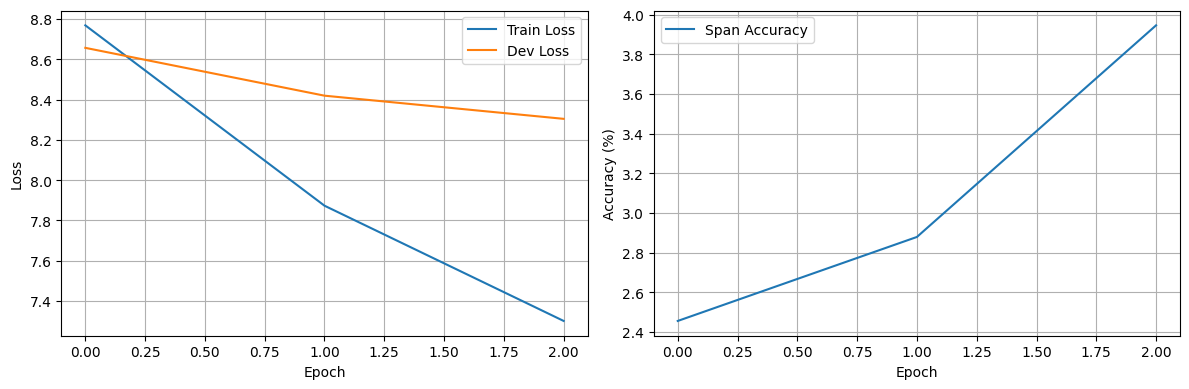


Experiment 2: Encoder-Decoder
Params: 10,637,754
Trainer on cuda, model: EncDec


Epoch 1/3:   0%|          | 0/1356 [00:00<?, ?it/s]

RuntimeError: The size of tensor a (13) must match the size of tensor b (64) at non-singleton dimension 0

In [8]:
# 主实验
if __name__ == "__main__":
    print("="*70)
    print("SQuAD QA with Custom Transformers")
    print("="*70)

    BATCH_SIZE = 64
    MAX_LEN = 384
    EPOCHS = 3   # 可改为 5 或 10

    train_loader, dev_loader, tokenizer = create_dataloaders(
        TRAIN_FILE, DEV_FILE, batch_size=BATCH_SIZE, max_length=MAX_LEN
    )
    vocab_size = tokenizer.vocab_size
    print(f"Vocabulary size: {vocab_size}")

    # Encoder-Only
    print("\n" + "="*70)
    print("Experiment 1: Encoder-Only")
    model1 = EncoderOnlyQA(vocab_size, d_model=256, nhead=8, num_layers=8,
                           dim_feedforward=512, max_len=MAX_LEN, dropout=0.1)
    print(f"Params: {sum(p.numel() for p in model1.parameters() if p.requires_grad):,}")
    trainer1 = QATrainer(model1, device)
    trainer1.train(train_loader, dev_loader, epochs=EPOCHS, lr=3e-4, opt_name='adamw')
    trainer1.save_model(os.path.join(CHECKPOINT_DIR, "EncoderOnlyQA_dmodl256_lay8_batch128_lr3_adamw.pt"))
    trainer1.plot_history()



In [1]:
# Encoder-Decoder
print("\n" + "="*70)
print("Experiment 2: Encoder-Decoder")
model2 = EncoderDecoderQA(vocab_size, d_model=128, nhead=8,
                          num_encoder_layers=6, num_decoder_layers=6,
                          dim_feedforward=512, max_len=MAX_LEN, dropout=0.1,
                          max_answer_len=50,
                          cls_token_id=tokenizer.cls_token_id,
                          sep_token_id=tokenizer.sep_token_id)
print(f"Params: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}")
trainer2 = QATrainer(model2, device)
trainer2.train(train_loader, dev_loader, epochs=EPOCHS, lr=6e-4, opt_name='adam')
trainer2.save_model(os.path.join(CHECKPOINT_DIR, "EncoderDecoderQA_dmodel128_lay6_batch128_lr6_adam.pt"))
trainer2.plot_history()

print("\n" + "="*70)
print("Final Results")
print(f"Encoder-Only    Best Span Acc: {trainer1.best_span_acc:.2f}%")
print(f"Encoder-Decoder Best Span Acc: {trainer2.best_span_acc:.2f}%")
print("="*70)


Experiment 2: Encoder-Decoder


NameError: name 'EncoderDecoderQA' is not defined

### 测试2


In [ ]:
# 主实验
if __name__ == "__main__":
    print("="*70)
    print("SQuAD QA with Custom Transformers")
    print("="*70)

    BATCH_SIZE = 128
    MAX_LEN = 384
    EPOCHS = 10   # 可改为 5 或 10

    train_loader, dev_loader, tokenizer = create_dataloaders(
        TRAIN_FILE, DEV_FILE, batch_size=BATCH_SIZE, max_length=MAX_LEN
    )
    vocab_size = tokenizer.vocab_size
    print(f"Vocabulary size: {vocab_size}")

    # Encoder-Only
    print("\n" + "="*70)
    print("Experiment 1: Encoder-Only")
    model1 = EncoderOnlyQA(vocab_size, d_model=256, nhead=8, num_layers=6,
                           dim_feedforward=512, max_len=MAX_LEN, dropout=0.05)
    print(f"Params: {sum(p.numel() for p in model1.parameters() if p.requires_grad):,}")
    trainer1 = QATrainer(model1, device)
    trainer1.train(train_loader, dev_loader, epochs=EPOCHS, lr=6e-4, opt_name='adamw')
    trainer1.save_model(os.path.join(CHECKPOINT_DIR, "EncoderOnlyQA_dmodel256_lay6_batch128_epoch10_adamw_lr6_batch128.pt"))
    trainer1.plot_history()

    # Encoder-Decoder
    print("\n" + "="*70)
    print("Experiment 2: Encoder-Decoder")
    model2 = EncoderDecoderQA(vocab_size, d_model=256, nhead=8,
                              num_encoder_layers=3, num_decoder_layers=3,
                              dim_feedforward=512, max_len=MAX_LEN, dropout=0.1,
                              max_answer_len=50,
                              cls_token_id=tokenizer.cls_token_id,
                              sep_token_id=tokenizer.sep_token_id)
    print(f"Params: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}")
    trainer2 = QATrainer(model2, device)
    trainer2.train(train_loader, dev_loader, epochs=EPOCHS, lr=3e-4, opt_name='sgd')
    trainer2.save_model(os.path.join(CHECKPOINT_DIR, "EncoderDecoderQA_dmodel256_lay3_epoch10_sgd_lr3_batch128.pt"))
    trainer2.plot_history()

    print("\n" + "="*70)
    print("Final Results")
    print(f"Encoder-Only    Best Span Acc: {trainer1.best_span_acc:.2f}%")
    print(f"Encoder-Decoder Best Span Acc: {trainer2.best_span_acc:.2f}%")
    print("="*70)

SQuAD QA with Custom Transformers


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizing:   0%|          | 0/86821 [00:00<?, ?it/s]

Skipped 75 examples (answer span not found)
Loaded 86821 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-train-v2.0.json


Tokenizing:   0%|          | 0/5928 [00:00<?, ?it/s]

Skipped 24 examples (answer span not found)
Loaded 5928 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-dev-v2.0.json
Vocabulary size: 30522

Experiment 1: Encoder-Only
Params: 11,042,306
Trainer on cuda, model: EncOnly


Epoch 1/10:   0%|          | 0/678 [00:00<?, ?it/s]

### 展示

In [ ]:
def load_model_and_demo(model_path, model_type='encoder_only',
                        d_model=256, num_layers=6, nhead=8, max_len=384):
    """
    加载保存的模型并进行案例展示

    Args:
        model_path: 模型权重文件路径 (.pt)
        model_type: 'encoder_only' 或 'encoder_decoder'
        d_model, num_layers, nhead, max_len: 模型超参数（需与训练时一致）
    """
    # 加载 tokenizer
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    vocab_size = tokenizer.vocab_size

    # 创建模型
    if model_type == 'encoder_only':
        model = EncoderOnlyQA(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=4 * d_model,
            max_len=max_len,
            dropout=0.1
        )
    else:
        model = EncoderDecoderQA(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=4 * d_model,
            max_len=max_len,
            dropout=0.1,
            max_answer_len=50,
            cls_token_id=tokenizer.cls_token_id,
            sep_token_id=tokenizer.sep_token_id
        )

    # 加载权重
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    print(f"✅ 模型加载成功: {model_path}")
    print(f"   最佳准确率: {checkpoint.get('best_acc', checkpoint.get('best_span_acc', 'N/A'))}")

    return model, tokenizer


def show_predictions(model, tokenizer, dev_loader, num_success=5, num_fail=5, model_type='encoder_only'):
    """
    展示成功和失败的预测案例
    """
    model.eval()
    success_cases = []
    fail_cases = []

    with torch.no_grad():
        for batch in tqdm(dev_loader, desc="Evaluating cases"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            start_pos = batch['start_pos'].to(device)
            end_pos = batch['end_pos'].to(device)

            if model_type == 'encoder_only':
                start_logits, end_logits = model(input_ids, attention_mask)
                pred_start = start_logits.argmax(dim=-1)
                pred_end = end_logits.argmax(dim=-1)

                for i in range(input_ids.size(0)):
                    is_correct = (pred_start[i] == start_pos[i]) and (pred_end[i] == end_pos[i])

                    # 解码文本
                    tokens = input_ids[i].cpu().tolist()
                    pred_answer = tokenizer.decode(tokens[pred_start[i]:pred_end[i]+1])
                    true_answer = tokenizer.decode(tokens[start_pos[i]:end_pos[i]+1])
                    question = tokenizer.decode(tokens[1:start_pos[i]-len(tokens)+1])  # 简化，获取问题部分

                    case = {
                        'question': batch.get('question', ['N/A'])[i] if 'question' in batch else "Question not stored",
                        'true_answer': true_answer,
                        'pred_answer': pred_answer,
                        'start_pos': (start_pos[i].item(), end_pos[i].item()),
                        'pred_pos': (pred_start[i].item(), pred_end[i].item())
                    }

                    if is_correct and len(success_cases) < num_success:
                        success_cases.append(case)
                    elif not is_correct and len(fail_cases) < num_fail:
                        fail_cases.append(case)

                    if len(success_cases) >= num_success and len(fail_cases) >= num_fail:
                        break

            else:  # encoder_decoder
                # 简化：对于 Encoder-Decoder，直接生成答案
                generated = model.generate(model.encode(input_ids, attention_mask), attention_mask)
                # 获取目标答案
                targets = []
                for i in range(input_ids.size(0)):
                    ans_tokens = input_ids[i, start_pos[i]:end_pos[i]+1]
                    targets.append(ans_tokens)

                for i in range(input_ids.size(0)):
                    pred_answer = tokenizer.decode(generated[i, 1:], skip_special_tokens=True)
                    true_answer = tokenizer.decode(targets[i], skip_special_tokens=True)

                    is_correct = (pred_answer.strip().lower() == true_answer.strip().lower())

                    case = {
                        'question': batch.get('question', ['N/A'])[i] if 'question' in batch else "Question not stored",
                        'true_answer': true_answer,
                        'pred_answer': pred_answer,
                    }

                    if is_correct and len(success_cases) < num_success:
                        success_cases.append(case)
                    elif not is_correct and len(fail_cases) < num_fail:
                        fail_cases.append(case)

                    if len(success_cases) >= num_success and len(fail_cases) >= num_fail:
                        break

            if len(success_cases) >= num_success and len(fail_cases) >= num_fail:
                break

    # 打印结果
    print("\n" + "="*80)
    print("✅ 成功案例 (模型预测正确)")
    print("="*80)
    for i, case in enumerate(success_cases):
        print(f"\n【案例 {i+1}】")
        print(f"  问题: {case['question'][:150]}...")
        print(f"  正确答案: {case['true_answer']}")
        print(f"  模型预测: {case['pred_answer']}")
        if 'start_pos' in case:
            print(f"  位置: GT={case['start_pos']}, Pred={case['pred_pos']}")

    print("\n" + "="*80)
    print("❌ 失败案例 (模型预测错误)")
    print("="*80)
    for i, case in enumerate(fail_cases):
        print(f"\n【案例 {i+1}】")
        print(f"  问题: {case['question'][:150]}...")
        print(f"  正确答案: {case['true_answer']}")
        print(f"  模型预测: {case['pred_answer']}")
        if 'start_pos' in case:
            print(f"  位置: GT={case['start_pos']}, Pred={case['pred_pos']}")

    return success_cases, fail_cases


# ==================== 使用示例 ====================
if __name__ == "__main__":
    # 请修改为你的实际模型路径
    MODEL_PATH = "/content/drive/MyDrive/SQuAD_checkpoints/EncoderOnlyQA_dmodel256_lay6_batch128_epoch10_adamw_lr3.pt"

    # 加载模型
    model, tokenizer = load_model_and_demo(
        model_path=MODEL_PATH,
        model_type='encoder_only',  # 或 'encoder_decoder'
        d_model=256,
        num_layers=6,
        nhead=8,
        max_len=384
    )

    # 重新创建 DataLoader（需要确保路径正确）
    train_loader, dev_loader, _ = create_dataloaders(
        TRAIN_FILE, DEV_FILE,  # 使用 Cell 1 中定义的路径
        batch_size=16,
        max_length=384
    )

    # 展示预测结果
    success, fail = show_predictions(
        model, tokenizer, dev_loader,
        num_success=5, num_fail=5,
        model_type='encoder_only'
    )


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SQuAD_checkpoints/EncoderOnlyQA_dmodel256_lay6_batch128_epoch10_adamw_lr3.pt'

### 由于自己实现的太差 调包使用预训练权重的试一下

In [ ]:
# Cell 7: 使用Hugging Face官方预训练模型微调（复用Cell 2的数据集）

from transformers import AutoTokenizer, AutoModelForQuestionAnswering, TrainingArguments, Trainer, default_data_collator
from datasets import Dataset as HFDataset

class HuggingFaceQATrainer:
    """
    使用Hugging Face官方预训练模型进行SQuAD问答任务微调
    复用Cell 2的SQuADDataset进行数据加载
    """

    def __init__(self, model_name="distilbert-base-uncased", device=None):
        self.model_name = model_name
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        print(f"Loading model: {model_name}")
        print(f"Using device: {self.device}")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForQuestionAnswering.from_pretrained(model_name)
        self.model.to(self.device)

        print(f"✅ Model loaded. Vocab size: {self.tokenizer.vocab_size}")
        print(f"   Parameters: {sum(p.numel() for p in self.model.parameters() if p.requires_grad):,}")

    def _convert_to_hf_dataset(self, squad_dataset):
        """
        将Cell 2的SQuADDataset转换为Hugging Face Dataset格式
        """
        hf_data = {
            'input_ids': squad_dataset.input_ids.numpy(),
            'attention_mask': squad_dataset.attention_mask.numpy(),
            'start_positions': squad_dataset.start_positions.numpy(),
            'end_positions': squad_dataset.end_positions.numpy()
        }
        return HFDataset.from_dict(hf_data)

    def train_from_dataloaders(self, train_loader, dev_loader, output_dir="./hf_qa_model",
                                epochs=3, learning_rate=3e-5):
        """
        直接使用Cell 2创建的DataLoader进行训练

        Args:
            train_loader: Cell 2返回的训练DataLoader
            dev_loader: Cell 2返回的验证DataLoader
            output_dir: 模型保存目录
            epochs: 训练轮数
            learning_rate: 学习率
        """
        print(f"\n📊 Converting datasets to HF format...")

        # 从DataLoader中提取原始Dataset
        train_dataset = train_loader.dataset
        dev_dataset = dev_loader.dataset

        # 转换为HF Dataset格式
        train_hf = self._convert_to_hf_dataset(train_dataset)
        dev_hf = self._convert_to_hf_dataset(dev_dataset)

        print(f"   Training samples: {len(train_hf)}")
        print(f"   Dev samples: {len(dev_hf)}")

        # 训练参数
        training_args = TrainingArguments(
            output_dir=output_dir,
            evaluation_strategy="epoch",
            save_strategy="epoch",
            learning_rate=learning_rate,
            per_device_train_batch_size=train_loader.batch_size,
            per_device_eval_batch_size=dev_loader.batch_size,
            num_train_epochs=epochs,
            weight_decay=0.01,
            logging_dir=f"{output_dir}/logs",
            logging_steps=100,
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            fp16=torch.cuda.is_available(),
            report_to="none",
        )

        # 创建Trainer
        self.trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_hf,
            eval_dataset=dev_hf,
            tokenizer=self.tokenizer,
            data_collator=default_data_collator,
        )

        # 开始训练
        print("\n🚀 Starting training...")
        self.trainer.train()

        # 保存最终模型
        self.trainer.save_model(output_dir)
        self.tokenizer.save_pretrained(output_dir)
        print(f"✅ Model saved to {output_dir}")

        return self.trainer

    def predict(self, question, context):
        """单条预测"""
        self.model.eval()
        inputs = self.tokenizer(
            question,
            context,
            return_tensors="pt",
            truncation=True,
            max_length=384
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)
            start_logits = outputs.start_logits
            end_logits = outputs.end_logits

        start_idx = start_logits.argmax().item()
        end_idx = end_logits.argmax().item()

        answer_tokens = inputs['input_ids'][0][start_idx:end_idx+1]
        answer = self.tokenizer.decode(answer_tokens, skip_special_tokens=True)

        return {
            'answer': answer,
            'start_position': start_idx,
            'end_position': end_idx
        }

    def show_predictions(self, dev_loader, num_examples=5):
        """使用验证集展示预测结果"""
        self.model.eval()

        print("\n" + "="*80)
        print("📝 预测案例展示 (使用验证集)")
        print("="*80)

        correct = 0
        shown = 0

        for batch in dev_loader:
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            start_pos = batch['start_pos']
            end_pos = batch['end_pos']

            with torch.no_grad():
                outputs = self.model(input_ids, attention_mask=attention_mask)
                pred_start = outputs.start_logits.argmax(dim=-1)
                pred_end = outputs.end_logits.argmax(dim=-1)

            for i in range(input_ids.size(0)):
                if shown >= num_examples:
                    break

                # 解码文本
                true_answer = self.tokenizer.decode(input_ids[i, start_pos[i]:end_pos[i]+1], skip_special_tokens=True)
                pred_answer = self.tokenizer.decode(input_ids[i, pred_start[i]:pred_end[i]+1], skip_special_tokens=True)

                # 提取问题（简单方法：取[CLS]和第一个[SEP]之间的内容）
                sep_pos = (input_ids[i] == 102).nonzero(as_tuple=True)[0]
                if len(sep_pos) > 0:
                    question_tokens = input_ids[i, 1:sep_pos[0]]
                    question = self.tokenizer.decode(question_tokens, skip_special_tokens=True)
                else:
                    question = "无法提取问题"

                is_correct = (true_answer.strip().lower() == pred_answer.strip().lower())
                if is_correct:
                    correct += 1

                print(f"\n【案例 {shown+1}】")
                print(f"  问题: {question[:100]}...")
                print(f"  正确答案: {true_answer}")
                print(f"  模型预测: {pred_answer}")
                print(f"  结果: {'✅ 正确' if is_correct else '❌ 错误'}")

                shown += 1

            if shown >= num_examples:
                break

        print(f"\n📊 展示案例准确率: {correct}/{num_examples} = {correct/num_examples*100:.1f}%")


# ==================== 使用示例 ====================
if __name__ == "__main__":
    print("="*70)
    print("Hugging Face 预训练模型微调 (DistilBERT)")
    print("="*70)

    # 使用Cell 2中已有的create_dataloaders函数创建DataLoader
    # 注意：Cell 2已经在之前运行过了，train_loader, dev_loader, tokenizer已经存在
    # 如果变量不存在，重新创建：
    try:
        # 尝试使用已有的loader
        existing_train_loader
        existing_dev_loader
        print("✅ 使用已有的DataLoader")
        train_loader = existing_train_loader
        dev_loader = existing_dev_loader
    except NameError:
        # 如果不存在，重新创建
        print("📂 重新创建DataLoader...")
        train_loader, dev_loader, _ = create_dataloaders(
            TRAIN_FILE, DEV_FILE,
            batch_size=16,
            max_length=384
        )

    # 创建HF Trainer
    hf_trainer = HuggingFaceQATrainer(
        model_name="distilbert-base-uncased",  # 轻量版，约66M参数
        device=device
    )

    # 微调（使用已有的DataLoader）
    hf_trainer.train_from_dataloaders(
        train_loader=train_loader,
        dev_loader=dev_loader,
        output_dir=os.path.join(CHECKPOINT_DIR, "distilbert_qa"),
        epochs=3,
        learning_rate=3e-5
    )

    # 展示预测结果
    hf_trainer.show_predictions(dev_loader, num_examples=10)

    print("\n✅ 完成！模型已保存到:", os.path.join(CHECKPOINT_DIR, "distilbert_qa"))

Hugging Face 预训练模型微调 (DistilBERT)
📂 重新创建DataLoader...


Tokenizing:   0%|          | 0/86821 [00:00<?, ?it/s]

Skipped 75 examples (answer span not found)
Loaded 86821 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-train-v2.0.json


Tokenizing:   0%|          | 0/5928 [00:00<?, ?it/s]

Skipped 24 examples (answer span not found)
Loaded 5928 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-dev-v2.0.json
Loading model: distilbert-base-uncased
Using device: cpu


...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
qa_outputs.bias         | MISSING    | 
qa_outputs.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded. Vocab size: 30522
   Parameters: 66,364,418

📊 Converting datasets to HF format...
   Training samples: 86746
   Dev samples: 5904


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'